# 03 · Evaluation, confusion matrices, Grad-CAM and failure analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/atilimai/plant-ai-project/blob/main/notebooks/03_evaluation_plan.ipynb)

Issues #06, #07, #08, #10. Everything here is computed on the **held-out test split** (leaf-level, audited).
Evaluation refuses to run on the test split if the committed leakage audit did not pass.

In [1]:
# Setup: on Colab clone the repo and install deps; locally just move to the repo root.
import os, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not Path("plant-ai-project").exists():
        !git clone -q https://github.com/atilimai/plant-ai-project.git
    %cd plant-ai-project
    !pip install -q -r requirements.txt
else:
    while not Path("configs/data.yaml").exists() and Path.cwd() != Path.cwd().parent:
        os.chdir("..")
sys.path.insert(0, str(Path.cwd()))
print("repo root:", Path.cwd().name)

repo root: plant-ai-project


## (Re)compute the reports

Skip this if `artifacts/reports/` is already populated. Needs the images and the checkpoints.

In [2]:
RUN_EVALUATION = False
RUNS = ["multiclass_mobilenet_v2", "multiclass_efficientnet_b0", "binary_mobilenet_v2", "binary_efficientnet_b0"]

if RUN_EVALUATION:
    from src.evaluation.evaluate import evaluate
    from src.evaluation import failure_analysis
    for run in RUNS:
        ckpt = f"models/checkpoints/{run}/best.pt"
        evaluate(ckpt, split="test")
        evaluate(ckpt, split="test", variant="segmented")
        failure_analysis.main(["--checkpoint", ckpt])

## Headline numbers

In [3]:
import io
import json

import pandas as pd
from IPython.display import Image as IPyImage, Markdown, display
from PIL import Image

from src.evaluation.summarize import summarize_runs


def show(path, width=900):
    """Embed a saved figure as a downscaled JPEG so the notebook stays small."""
    img = Image.open(path).convert("RGB")
    img.thumbnail((width * 2, width * 4))
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=85)
    display(IPyImage(data=buf.getvalue(), format="jpeg", width=width))


pd.set_option("display.precision", 4)
summary = summarize_runs()
cols = ["run", "split", "variant", "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "ece"]
summary[summary["split"] == "test"][cols]

# Results summary

All numbers come from `metrics.json` files written by `src.evaluation.evaluate`.
Test is the leaf-level held-out split (see `data/splits/README.md`). The two extra rows
per run are the same test photos with the background changed: `segmented` is the
dataset's background-removed copy (black), `segmented_gray` puts the leaf on a flat
background in the colour of the lab table. See `docs/results.md`.

## Multiclass

| run | split | accuracy | balanced_accuracy | macro_f1 | weighted_f1 | top3_accuracy | ece |
|---|---|---|---|---|---|---|---|
| multiclass_efficientnet_b0 | test | 0.9952 | 0.9939 | 0.9938 | 0.9952 | 0.9992 | 0.1435 |
| multiclass_efficientnet_b0 | test (segmented) | 0.8028 | 0.7865 | 0.7879 | 0.8240 | 0.9532 | 0.0961 |
| multiclass_efficientnet_b0 | test (segmented_gray) | 0.8430 | 0.8358 | 0.8131 | 0.8491 | 0.9649 | 0.1132 |
| multiclass_efficientnet_b0 | val | 0.9959 | 0.9933 | 0.9898 | 0.9960 | 0.9991 | 0.1448 |
| multiclass_mobilenet_v2 | test | 0.9932

,run,split,variant,accuracy,balanced_accuracy,macro_f1,weighted_f1,ece
0,binary_efficientnet_b0,test,color,0.9985,0.9981,0.9981,0.9985,0.0660
1,binary_efficientnet_b0,test,segmented,0.9735,0.9578,0.9666,0.9732,0.0585
2,binary_efficientnet_b0,test,segmented_gray,0.9704,0.9536,0.9628,0.9701,0.0695
4,binary_mobilenet_v2,test,color,0.9986,0.9982,0.9982,0.9986,0.0638
5,binary_mobilenet_v2,test,segmented,0.9762,0.9744,0.9709,0.9763,0.0599
6,binary_mobilenet_v2,test,segmented_gray,0.9656,0.9580,0.9576,0.9656,0.0607
8,multiclass_efficientnet_b0,test,color,0.9952,0.9939,0.9938,0.9952,0.1435
9,multiclass_efficientnet_b0,test,segmented,0.8028,0.7865,0.7879,0.8240,0.0961
10,multiclass_efficientnet_b0,test,segmented_gray,0.8430,0.8358,0.8131,0.8491,0.1132
12,multiclass_mobilenet_v2,test,color,0.9932,0.9922,0.9905,0.9932,0.1421


## Multiclass: per-class results and confusion matrix (MobileNetV2)

In [4]:
RUN = "multiclass_mobilenet_v2"
per_class = pd.read_csv(f"artifacts/reports/{RUN}/test/per_class_metrics.csv")
per_class.sort_values("f1").head(10)

,class,precision,recall,f1,support
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.9298,0.9464,0.9381,56
22,Potato___healthy,0.8889,1.0000,0.9412,24
9,Corn_(maize)___Northern_Leaf_Blight,0.9675,0.9597,0.9636,124
29,Tomato___Early_blight,0.9592,0.9724,0.9658,145
30,Tomato___Late_blight,0.9650,0.9841,0.9745,252
28,Tomato___Bacterial_spot,0.9744,0.9776,0.9760,312
34,Tomato___Target_Spot,0.9738,0.9789,0.9764,190
32,Tomato___Septoria_leaf_spot,0.9821,0.9821,0.9821,224
21,Potato___Late_blight,1.0000,0.9662,0.9828,148
31,Tomato___Leaf_Mold,0.9862,0.9931,0.9896,144


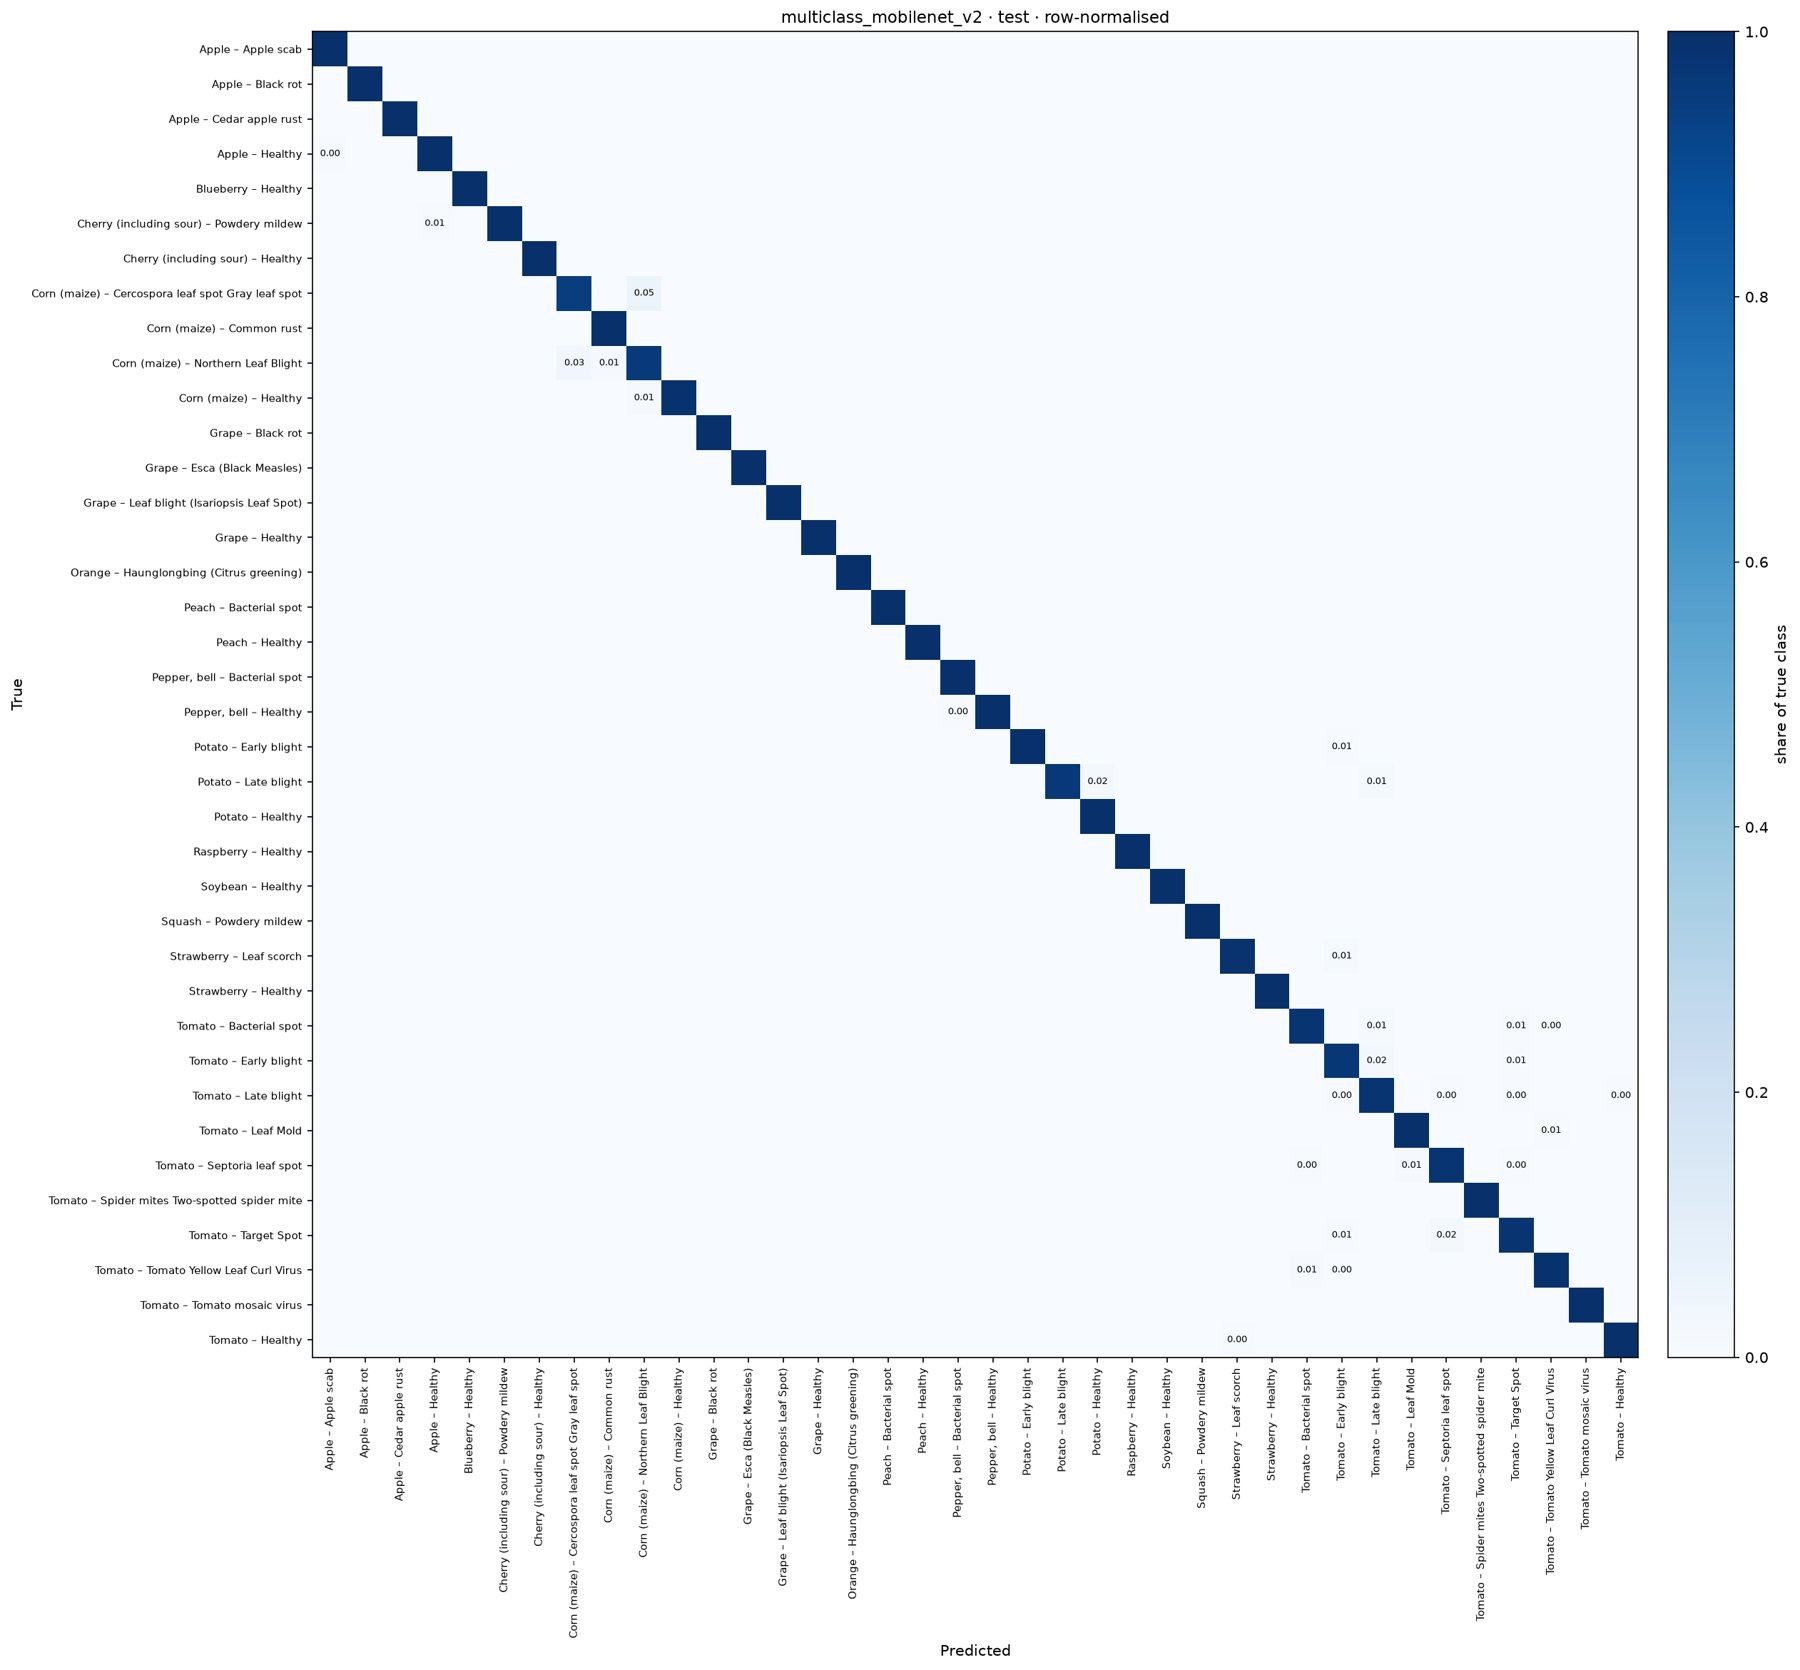

In [5]:
show(f"artifacts/figures/{RUN}/confusion_matrix_test_normalized.png", width=900)

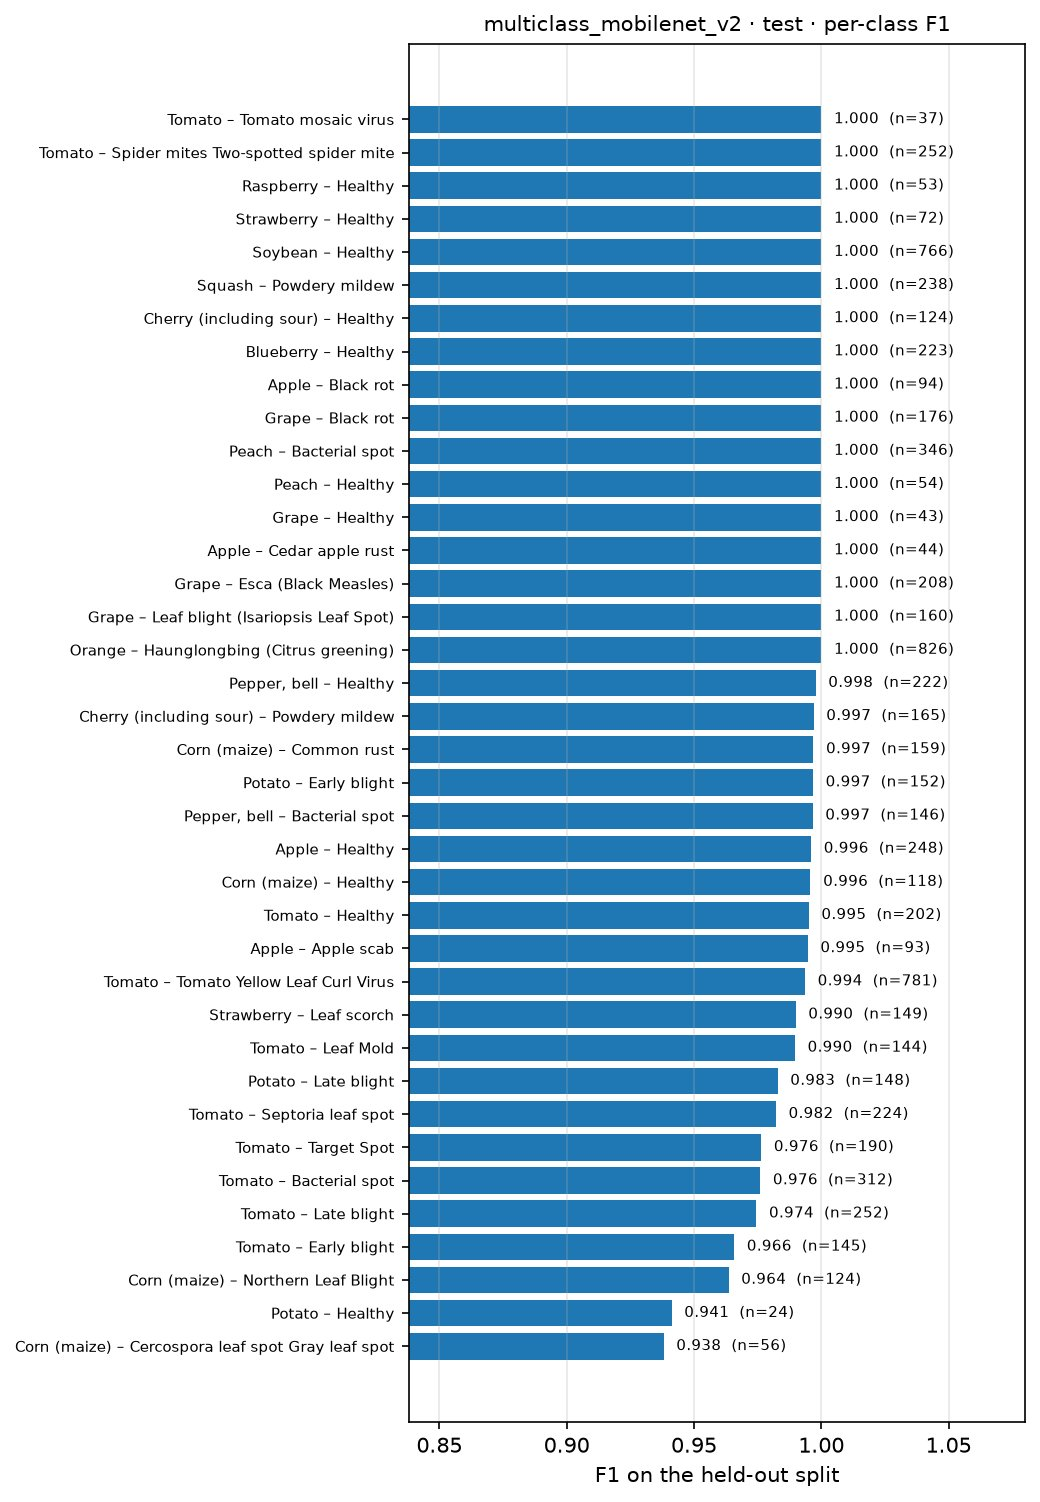

In [6]:
show(f"artifacts/figures/{RUN}/per_class_f1_test.png", width=550)

In [7]:
metrics = json.load(open(f"artifacts/reports/{RUN}/test/metrics.json"))
pd.DataFrame(metrics["top_confusions"]).head(10)

,true,predicted,count,share_of_true_class
0,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___Bacterial_spot,7,0.0090
1,Tomato___Bacterial_spot,Tomato___Late_blight,4,0.0128
2,Corn_(maize)___Northern_Leaf_Blight,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,4,0.0323
3,Potato___Late_blight,Potato___healthy,3,0.0203
4,Tomato___Early_blight,Tomato___Late_blight,3,0.0207
5,Tomato___Target_Spot,Tomato___Septoria_leaf_spot,3,0.0158
6,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight,3,0.0536
7,Potato___Late_blight,Tomato___Late_blight,2,0.0135
8,Strawberry___Leaf_scorch,Tomato___Early_blight,2,0.0134
9,Tomato___Septoria_leaf_spot,Tomato___Leaf_Mold,2,0.0089


## Binary track

binary_mobilenet_v2: acc 0.9986 · sensitivity 0.9991 · specificity 0.9972 · ROC-AUC 0.9999 · missed diseased leaves 5
binary_efficientnet_b0: acc 0.9985 · sensitivity 0.9989 · specificity 0.9972 · ROC-AUC 1.0000 · missed diseased leaves 6


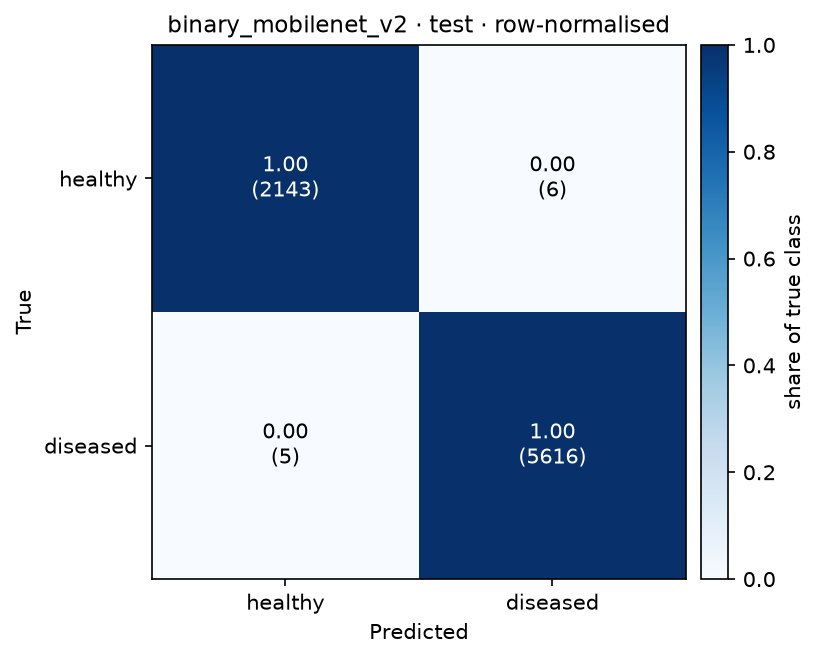

In [8]:
for run in ("binary_mobilenet_v2", "binary_efficientnet_b0"):
    m = json.load(open(f"artifacts/reports/{run}/test/metrics.json"))
    print(f"{run}: acc {m['accuracy']:.4f} · sensitivity {m['sensitivity']:.4f} · specificity {m['specificity']:.4f} "
          f"· ROC-AUC {m['roc_auc']:.4f} · missed diseased leaves {m['false_negatives']}")
show("artifacts/figures/binary_mobilenet_v2/confusion_matrix_test_normalized.png", width=420)

## Calibration

How far confidence can be trusted. Points below the diagonal are over-confident.

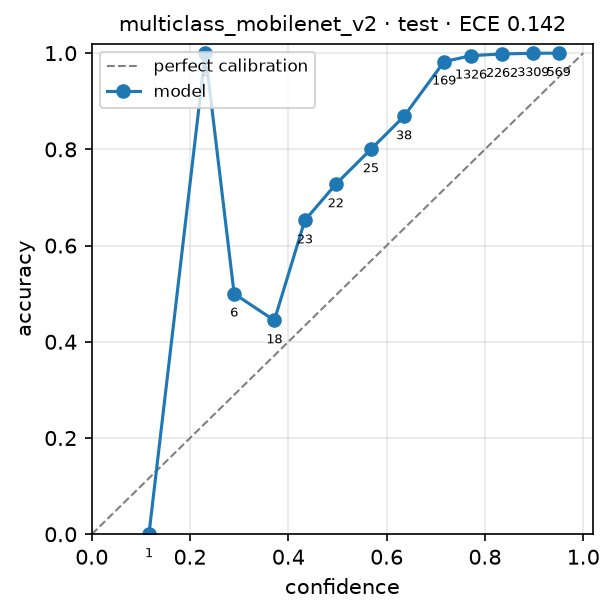

In [9]:
show(f"artifacts/figures/{RUN}/reliability_test.png", width=380)

## Grad-CAM (issue #08)

Layer: `model.features[-1]`, the last convolutional block (7×7 at 224 px). Correct predictions first, then the most confident mistakes.

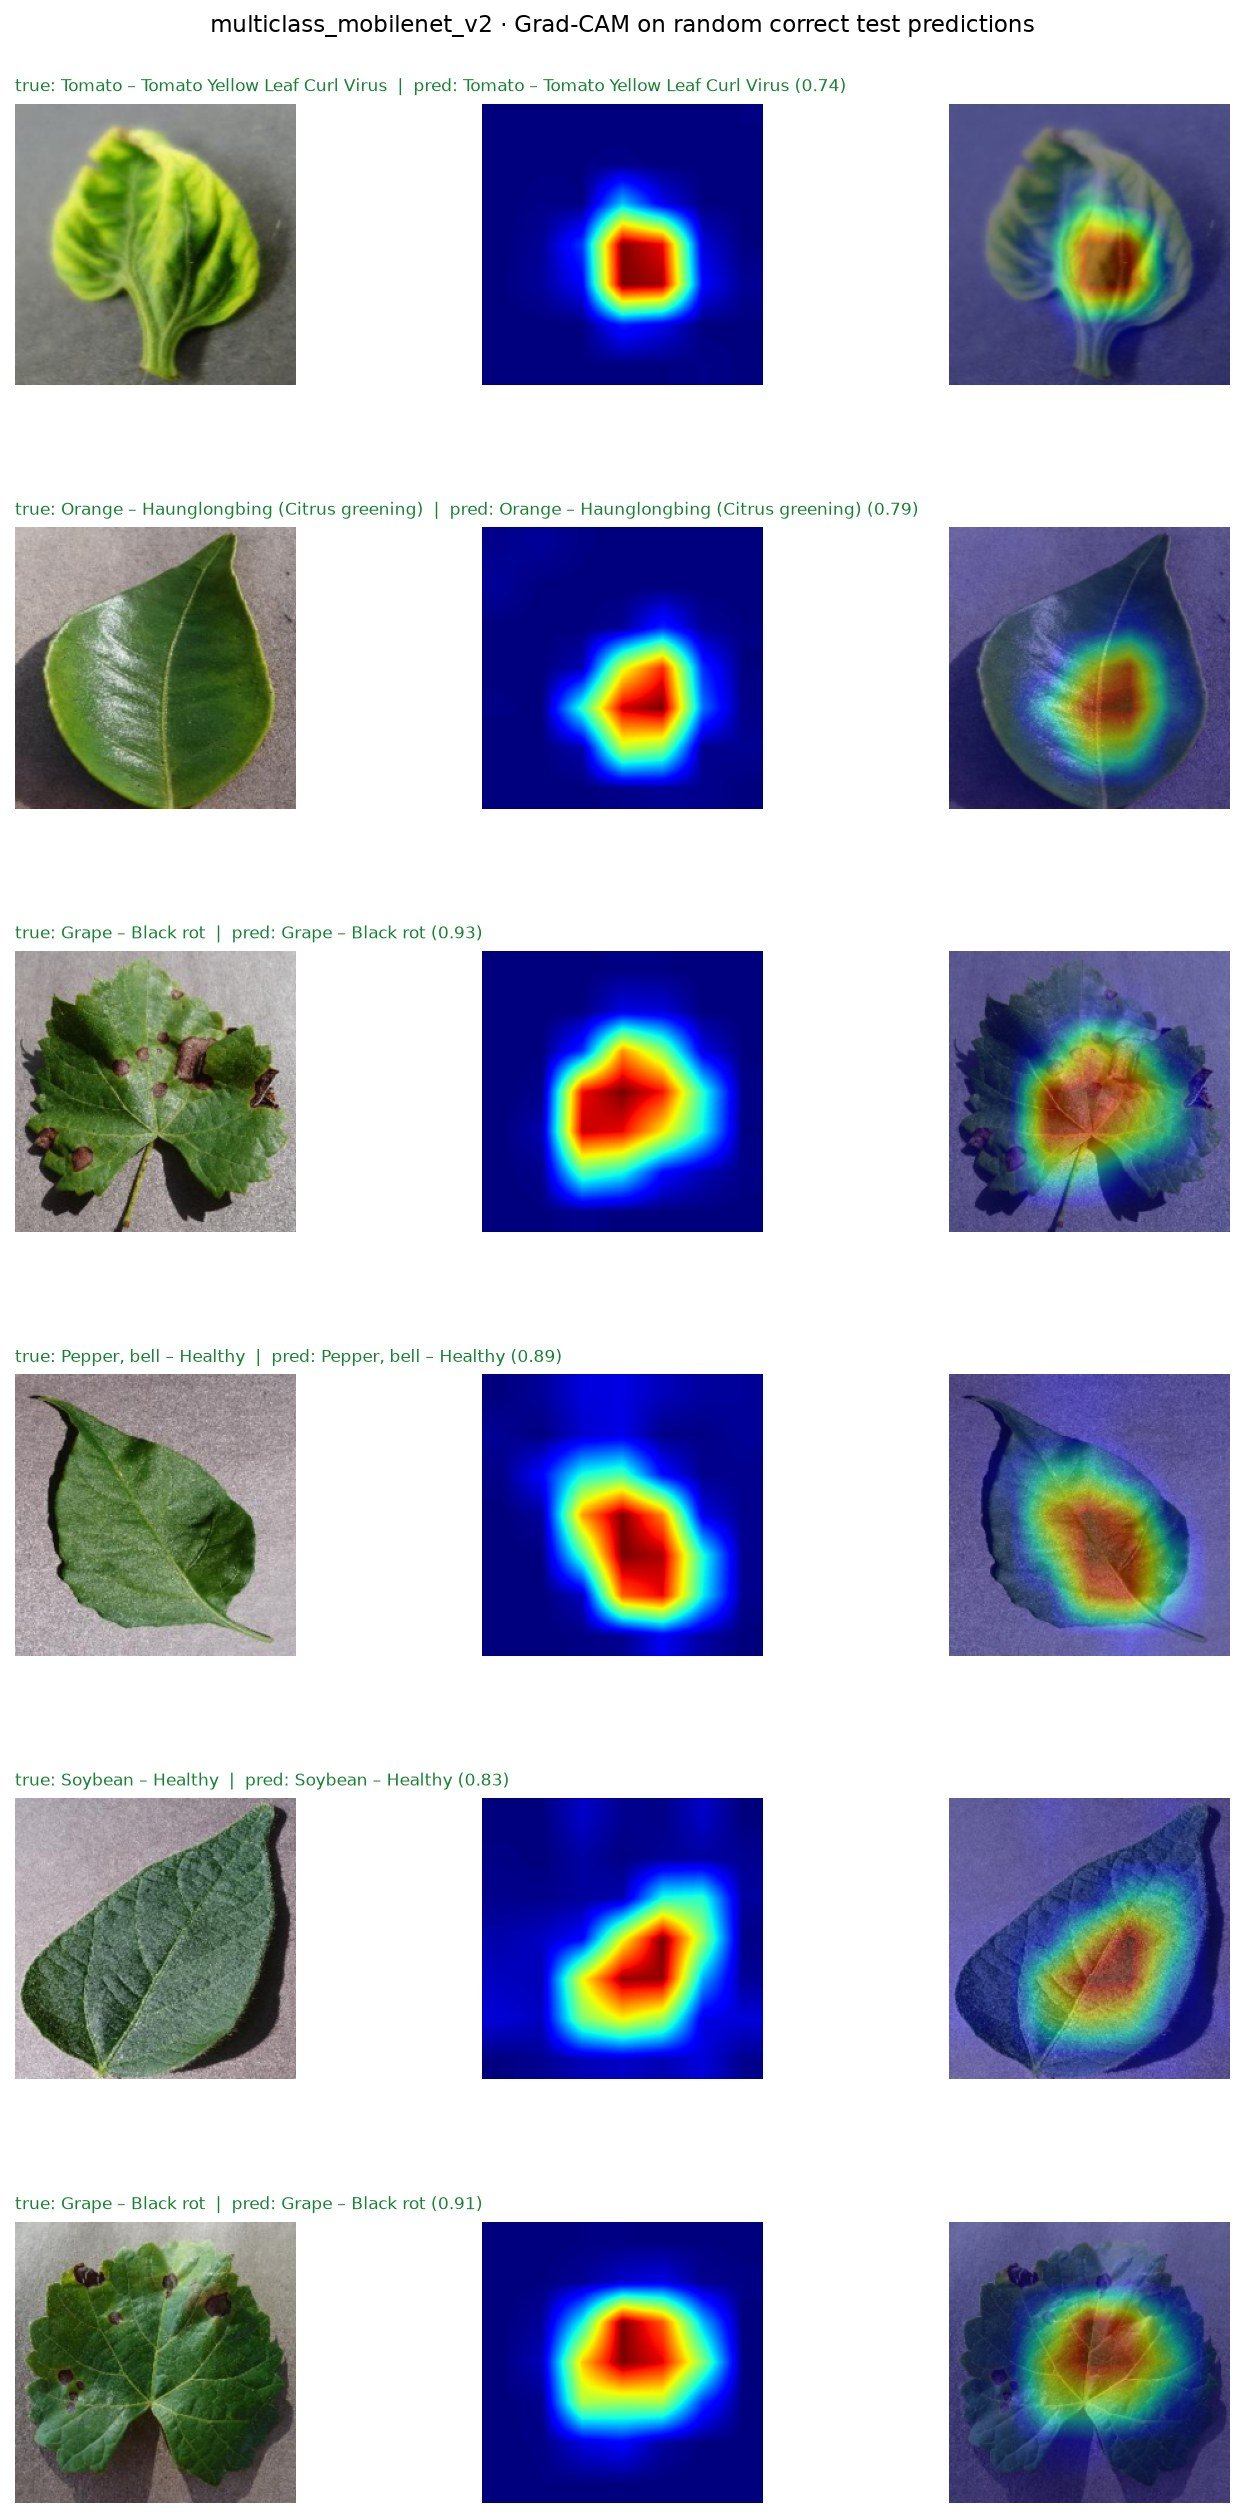

In [10]:
show(f"artifacts/figures/{RUN}/gradcam_correct.jpg", width=700)

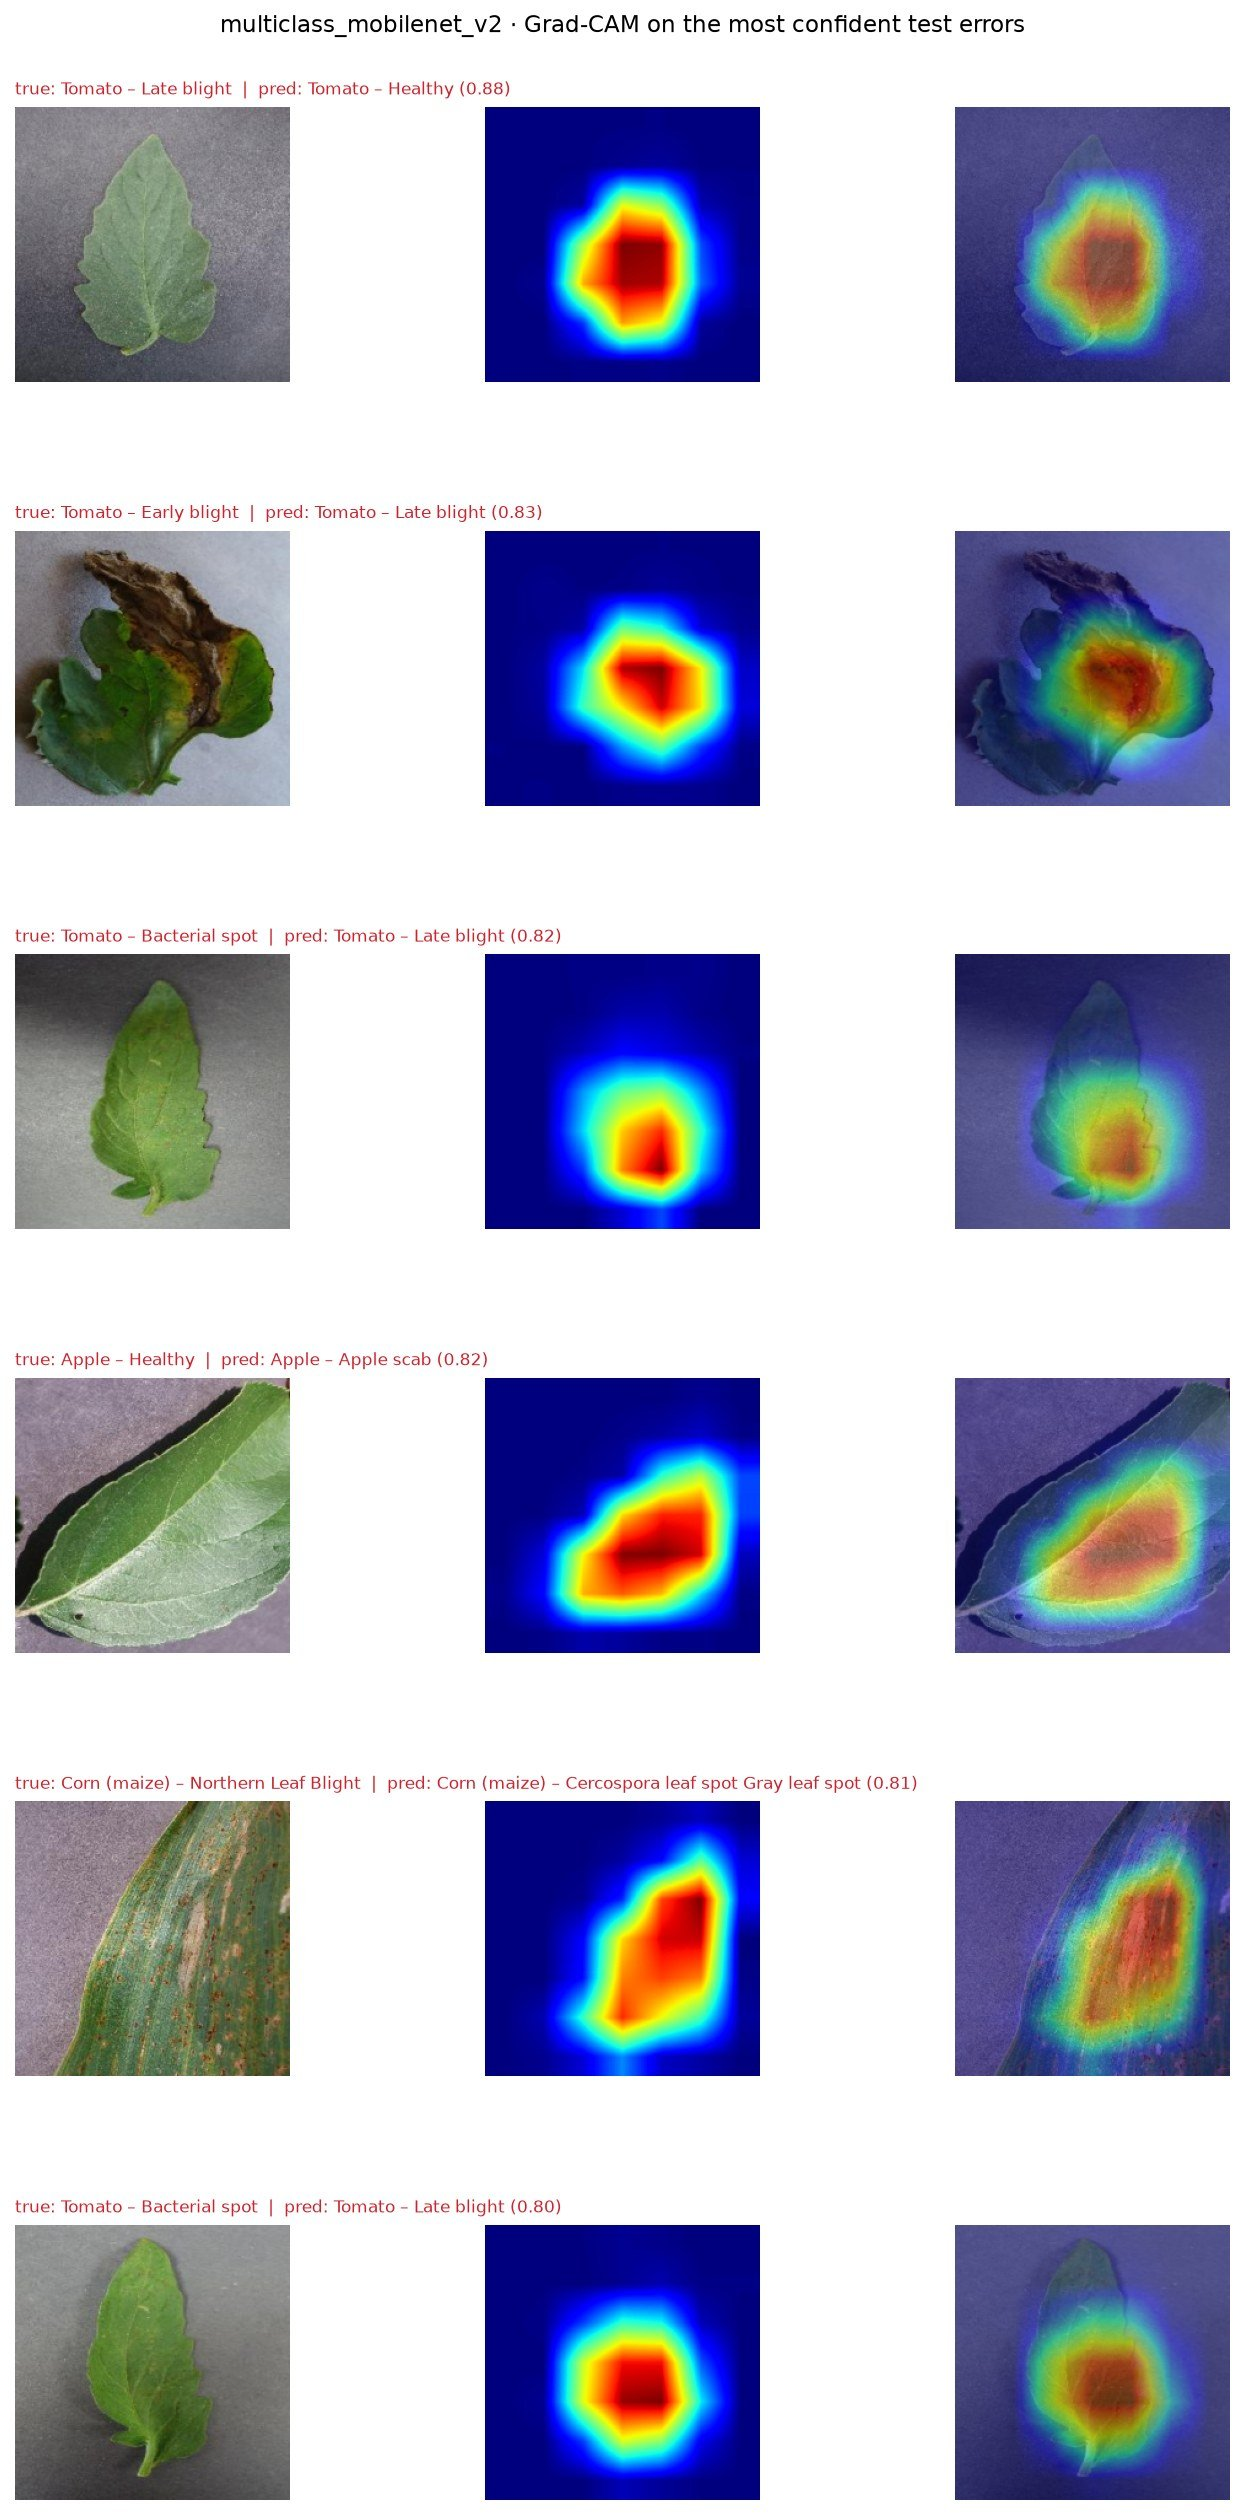

In [11]:
show(f"artifacts/figures/{RUN}/gradcam_errors.jpg", width=700)

## Failure analysis (issue #10)

In [12]:
display(Markdown(open(f"artifacts/reports/{RUN}/failure_analysis.md", encoding="utf-8").read()))

# Failure analysis — `multiclass_mobilenet_v2` (test split)

Generated by `python -m src.evaluation.failure_analysis`. Numbers only; the
interpretation lives in `docs/results.md`.

## Error overview

| metric | value |
|---|---|
| n_images | 7770 |
| n_errors | 53 |
| error_rate | 0.0068 |
| confident_errors_over_0.9 | 0 |
| error_confidence_median | 0.4956 |
| correct_confidence_median | 0.8670 |
| errors_within_same_crop | 46 |
| errors_across_crops | 7 |
| healthy_predicted_as_diseased | 4 |
| diseased_predicted_as_healthy | 5 |
| disease_confused_with_other_disease | 44 |

## Most frequent confusions

| true | predicted | count |
|---|---|---:|
| Tomato – Tomato Yellow Leaf Curl Virus | Tomato – Bacterial spot | 7 |
| Tomato – Bacterial spot | Tomato – Late blight | 4 |
| Corn (maize) – Northern Leaf Blight | Corn (maize) – Cercospora leaf spot Gray leaf spot | 4 |
| Potato – Late blight | Potato – Healthy | 3 |
| Corn (maize) – Cercospora leaf spot Gray leaf spot | Corn (maize) – Northern Leaf Blight | 3 |
| Tomato – Early blight | Tomato – Late blight | 3 |
| Tomato – Target Spot | Tomato – Septoria leaf spot | 3 |
| Tomato – Bacterial spot | Tomato – Target Spot | 2 |
| Potato – Late blight | Tomato – Late blight | 2 |
| Tomato – Septoria leaf spot | Tomato – Leaf Mold | 2 |
| Strawberry – Leaf scorch | Tomato – Early blight | 2 |
| Apple – Healthy | Apple – Apple scab | 1 |
| Cherry (including sour) – Powdery mildew | Apple – Healthy | 1 |
| Pepper, bell – Healthy | Pepper, bell – Bacterial spot | 1 |
| Corn (maize) – Healthy | Corn (maize) – Northern Leaf Blight | 1 |

## Error rate by crop

| crop | error rate |
|---|---:|
| Corn_(maize) | 1.97% |
| Potato | 1.85% |
| Tomato | 1.30% |
| Strawberry | 0.90% |
| Cherry_(including_sour) | 0.35% |
| Pepper,_bell | 0.27% |
| Apple | 0.21% |
| Orange | 0.00% |
| Blueberry | 0.00% |
| Grape | 0.00% |
| Raspberry | 0.00% |
| Peach | 0.00% |
| Squash | 0.00% |
| Soybean | 0.00% |

## Where the model looks (Grad-CAM mass on the leaf)

`cam_on_leaf` is the share of Grad-CAM mass inside the leaf mask taken from the
segmented copy of the image; `leaf_area` is the share of the image the leaf covers.
A ratio above 1 means attention is concentrated on the leaf.

| subset | images | leaf_area | cam_on_leaf | focus_ratio |
|---|---:|---:|---:|---:|
| correct | 396 | 0.476 | 0.903 | 2.03 |
| errors | 53 | 0.429 | 0.795 | 2.02 |

## Same test photos with the background changed

`segmented` is the dataset's background-removed copy (black outside the leaf);
`segmented_gray` puts the same leaf on a flat background in the colour of the lab
table, which keeps the image plausible and isolates the information the background
carried from the shock of an unseen black frame.

| metric | color | segmented | segmented_gray |
|---|---|---|---|
| accuracy | 0.9932 | 0.7259 | 0.8649 |
| macro_f1 | 0.9905 | 0.7513 | 0.8335 |
| balanced_accuracy | 0.9922 | 0.7358 | 0.8761 |


The written interpretation of these numbers is in [`docs/results.md`](../docs/results.md).